# 10.4.2 观测误差与输出反馈

## 学习目标与先修知识

推导观测（observation）器误差动态，并用估计状态（state）而非真值决策。

先修：10.4.1能观性（observability）、第7.3章状态估计与10.3.2状态反馈（feedback）。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

只测到一部分状态时，怎样让反馈律仍能使用状态信息？答案不是让控制器访问隐藏真值，而是维护一个由模型（model）、真实执行输入（input）和读数更新的估计。

In [1]:
import math
import itertools
import ast
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

从初始估计[0,0]出发，读数为2；C=[1,0]，L=[0.5,0.25]ᵀ。先计算创新与第一步校正。

In [2]:
initial=np.array([0.,0.]);C=np.array([1.,0.]);L=np.array([.5,.25]);print("创新与校正：",2.-C@initial,(L*(2.-C@initial)).tolist())

创新与校正： 2.0 [1.0, 0.5]


## 模型假设

离散线性对象 $x_{n+1}=Ax_n+Bu_n$，读数 $y_n=Cx_n$。A、B、C与实际执行u已知。先在无噪、无饱和、模型准确条件下推导误差；图示再加人工测量噪声（measurement noise）。估计器初态可以不等于真态。状态反馈用 $u=-K\hat x$，而不是 $-Kx$。

## 数学解释与推导

观测器（state observer）按
$$\hat x_{n+1}=A\hat x_n+Bu_n+L(y_n-C\hat x_n)$$
更新。括号内是创新，单位与测量相同。若 $e_n=x_n-\hat x_n$，在无噪且估计器使用同一真实输入时相减得
$$e_{n+1}=(A-LC)e_n.$$
因此选L要让A−LC的特征值（eigenvalue）在单位圆内。状态反馈 $u=-K\hat x$ 代回系统后，用 $(x,e)$ 排列的增广矩阵（matrix）为
$$\begin{bmatrix}A-BK&BK\\0&A-LC\end{bmatrix};$$
它是上三角分块，理想线性条件下极点（pole）由反馈与观测误差两组极点共同组成。这是分离设计的理由，也展示其条件：饱和、噪声、错模型和缺测会改变实际误差与闭环。

拓展提示：完整能观性允许任意配置观测误差极点；若不可观模态（mode）的离散时间特征值（eigenvalue）模长（modulus）均小于1，较弱的可检测性（detectability）仍可能足以让误差收敛。下面的例子满足完整能观性。

## 核心实现

将刚才推导的关系逐步写成函数。

In [3]:
def observer_path(A, B, C, L, inputs, readings, initial):
    """Discrete observer, known inputs and readings; no hidden true state."""
    estimate = list(initial)
    path = [estimate.copy()]
    innovations = []
    for u, y in zip(inputs, readings):
        innovation = y - sum(C[j] * estimate[j] for j in range(2))
        estimate = [sum(A[i][j] * estimate[j] for j in range(2))
                    + B[i] * u + L[i] * innovation for i in range(2)]
        innovations.append(innovation)
        path.append(estimate)
    return path, innovations

## 对照实验

先用给定读数重放估计器，再在相同对象和反馈增益（gain）下比较完整状态反馈与部分观测反馈。真值只进入离线曲线和误差检查，控制输入由估计产生。

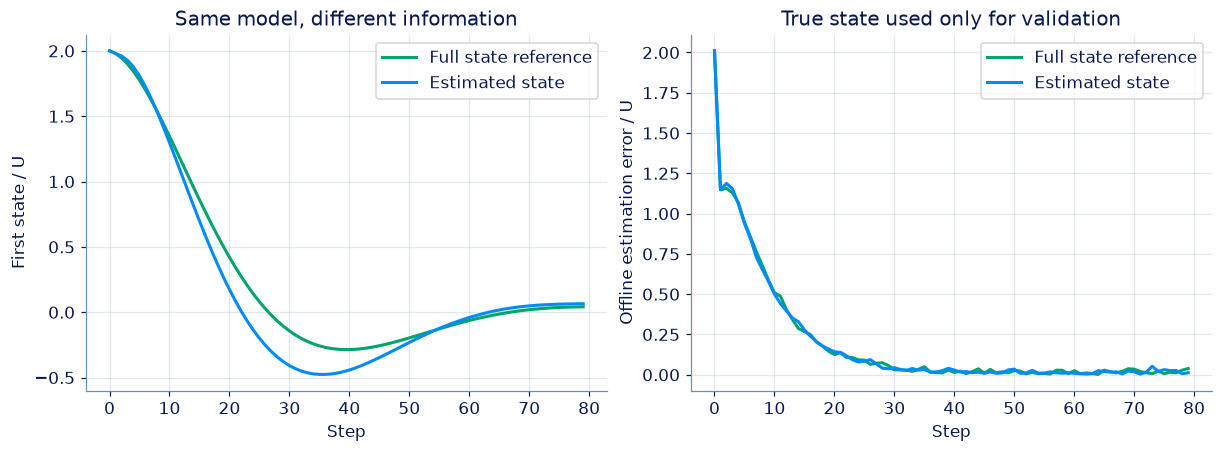

In [4]:
A=np.array([[1.,.1],[0.,.95]]);B=np.array([0.,.1]);C=np.array([1.,0.]);L=np.array([.7,.4]);K=np.array([.8,.5])
fig,axes=plt.subplots(1,2,figsize=(11,4));rng=np.random.default_rng(1042)
for full,color in [(True,GREEN),(False,BLUE)]:
    x=np.array([2.,-.2]);estimate=np.array([0.,0.]);states=[];errors=[]
    for _ in range(80):
        y=float(C@x+rng.normal(0,.025));u=-float(K@(x if full else estimate))
        states.append(x[0]);errors.append(np.linalg.norm(x-estimate))
        next_estimate=A@estimate+B*u+L*(y-C@estimate)
        x=A@x+B*u;estimate=next_estimate
    axes[0].plot(states,label='Full state reference' if full else 'Estimated state',color=color)
    axes[1].plot(errors,label='Full state reference' if full else 'Estimated state',color=color)
axes[0].set(xlabel='Step',ylabel='First state / U',title='Same model, different information');axes[0].legend()
axes[1].set(xlabel='Step',ylabel='Offline estimation error / U',title='True state used only for validation');axes[1].legend();plt.show()

## 结果解释

估计初态错误会造成早期反馈差异；本例观测器逐步吸收读数后，输出（output）反馈接近完整状态参考。完整状态参考展示了额外信息的作用；带噪曲线则展示固定随机种子（random seed）下的一次实现（realization）。

### 独立核对

独立核验A−LC与A−BK的特征值在单位圆内，并对无噪给定读数以直接递推检查观测器实现。

In [5]:
assert max(abs(np.linalg.eigvals(A-np.outer(L,C))))<1
assert max(abs(np.linalg.eigvals(A-np.outer(B,K))))<1
path,innov=observer_path(A.tolist(),B.tolist(),C.tolist(),L.tolist(),[0.],[2.],[0.,0.])
np.testing.assert_allclose(path[1],2*L);assert innov==[2.]
print('误差/反馈极点与手算首步校正一致。')

误差/反馈极点与手算首步校正一致。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/10-04-%E7%8A%B6%E6%80%81%E8%A7%82%E6%B5%8B%E5%99%A8%E4%B8%8E%E8%BE%93%E5%87%BA%E5%8F%8D%E9%A6%88/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：重放一次状态估计

离散二维线性观测（observation）器：xhat_next=A·xhat+B·u+L(y−C·xhat)。给定已知输入（input）和实际读数，返回含初值（initial condition）的估计轨迹（trajectory）与每步创新；不能在算法中访问隐藏真值。

**函数与代码模板**

```python
def solve(
    A: list[list[float]],
    B: list[float],
    C: list[float],
    L: list[float],
    inputs: list[float],
    readings: list[float],
    initial: list[float],
) -> tuple[list[list[float]], list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `A` | `list[list[float]]` | 2×2 离散状态（state）矩阵（matrix）。 | 按状态定义 |
| `B` | `list[float]` | 长度2的输入列。 | 状态/输入 |
| `C` | `list[float]` | 长度2的观测行。 | 观测/状态 |
| `L` | `list[float]` | 长度2的观测器增益（gain）列。 | 状态/观测 |
| `inputs` | `list[float]` | 每步真实执行输入，和readings等长。 | 输入单位 |
| `readings` | `list[float]` | 每步更新前取得的读数。 | 观测单位 |
| `initial` | `list[float]` | 初始估计，长度2。 | 状态单位 |

**返回值**

按以下顺序返回元组：(path, innovations)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `path` | `list[list[float]]` | 含初值与每次更新后的估计。 | 状态单位 |
| `innovations` | `list[float]` | 每步 y−C·xhat。 | 观测单位 |

**计算规则**

逐步用更新前估计计算创新，随后进行状态预测加校正；两列表长度相同。

**约束与边界**

- 输入均为有限数；只需实现题定模型（model），不外推到真实病人或设备。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| A | 2×2 离散状态（state）矩阵（matrix）。 | [[1.0, 1.0], [0.0, 1.0]] | 按状态定义 |
| B | 长度2的输入列。 | [0.0, 1.0] | 状态/输入 |
| C | 长度2的观测行。 | [1.0, 0.0] | 观测/状态 |
| L | 长度2的观测器增益（gain）列。 | [0.5, 0.25] | 状态/观测 |
| inputs | 每步真实执行输入，和readings等长。 | [0.0, 1.0, 0.0] | 输入单位 |
| readings | 每步更新前取得的读数。 | [2.0, 2.5, 4.0] | 观测单位 |
| initial | 初始估计，长度2。 | [0.0, 0.0] | 状态单位 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
A = [[1.0, 1.0], [0.0, 1.0]]
B = [0.0, 1.0]
C = [1.0, 0.0]
L = [0.5, 0.25]
inputs = [0.0, 1.0, 0.0]
readings = [2.0, 2.5, 4.0]
initial = [0.0, 0.0]

result = solve(A, B, C, L, inputs, readings, initial)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| path | 含初值与每次更新后的估计。 | [[0.0, 0.0], [1.0, 0.5], [2.25, 1.875], [5.0, 2.3125]] | 状态单位 |
| innovations | 每步 y−C·xhat。 | [2.0, 1.5, 1.75] | 观测单位 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[0.0, 0.0],
                    [1.0, 0.5],
                    [2.25, 1.875],
                    [5.0, 2.3125]],
                   [2.0, 1.5, 1.75])
```

**样例解释**

首步创新为2；校正只读y而不读隐藏x。L=0 时即使读数异常也不改变预测。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：重放一次状态估计](http://127.0.0.1:8000/chapters/10-04-%E7%8A%B6%E6%80%81%E8%A7%82%E6%B5%8B%E5%99%A8%E4%B8%8E%E8%BE%93%E5%87%BA%E5%8F%8D%E9%A6%88/practice/?question=p10-observer-replay)

### 第 2 题 · 单项选择题：误差如何演化

同一离散线性对象，观测（observation）器使用真实执行输入（input）且无过程与测量噪声（measurement noise）。定义 e=x−xhat，哪项正确？

- **A.** e_next=(A−LC)e。
- **B.** e_next=(A+LC)e。
- **C.** 只要L非零，误差一步归零。
- **D.** 误差必等于读数创新。

[作答：误差如何演化](http://127.0.0.1:8000/chapters/10-04-%E7%8A%B6%E6%80%81%E8%A7%82%E6%B5%8B%E5%99%A8%E4%B8%8E%E8%BE%93%E5%87%BA%E5%8F%8D%E9%A6%88/practice/?question=p10-error-dynamics)

### 第 3 题 · 单项选择题：分离设计的适用条件

状态（state）反馈（feedback）和观测（observation）器分别有稳定误差动态。哪项说法最完整？

- **A.** 在线性、模型（model）正确、无饱和等条件下可由两组极点（pole）构成增广闭环；加入限幅和失配后须重新验证。
- **B.** 无论传感器失效或执行器饱和，两组极点仍证明全局稳定。
- **C.** 反馈可以暗中使用实验用隐藏真值。
- **D.** 观测器增益（gain）和反馈增益必须数值相等。

[作答：分离设计的适用条件](http://127.0.0.1:8000/chapters/10-04-%E7%8A%B6%E6%80%81%E8%A7%82%E6%B5%8B%E5%99%A8%E4%B8%8E%E8%BE%93%E5%87%BA%E5%8F%8D%E9%A6%88/practice/?question=p10-separation-assumptions)

### 第 4 题 · 单项选择题：真值只能在哪里出现

教学模拟能保存完整状态（state），但真实传感器只给出 y。哪种做法合理？

- **A.** 控制决策只用y及其估计，模拟真值单独用于离线误差核验。
- **B.** 用真值计算u，再把结果称为部分观测（observation）控制。
- **C.** 把真值放入公开练习参数（parameter），却声称无需它。
- **D.** 没有真值就不能展示创新序列。

[作答：真值只能在哪里出现](http://127.0.0.1:8000/chapters/10-04-%E7%8A%B6%E6%80%81%E8%A7%82%E6%B5%8B%E5%99%A8%E4%B8%8E%E8%BE%93%E5%87%BA%E5%8F%8D%E9%A6%88/practice/?question=p10-truth-for-validation)

**进一步阅读**

[MIT OpenCourseWare，Feedback Control Systems 课程讲义](https://ocw.mit.edu/courses/16-30-feedback-control-systems-fall-2010/pages/lecture-notes/)：按主题阅读 PID、频域、能控、观测器和线性二次调节；本教材的模型与数值为独立教学例。